# 01 · Exploratory Data Analysis
Understand the data before modelling: seasonal peaks, how many weeks after rain
cases rise (lag-correlation), monthly seasonality, distribution and stationarity.
**Reads** `data/processed/dengue_weekly.csv` (from 00).

In [1]:
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
try:
    from google.colab import drive; drive.mount('/content/drive')
    BASE = '/content/drive/MyDrive/dengue-bd'
except Exception:
    BASE = os.path.abspath('dengue-bd')
df = pd.read_csv(f'{BASE}/data/processed/dengue_weekly.csv', parse_dates=['week'])
plt.rcParams['figure.figsize'] = (9, 4)
print('Loaded', len(df), 'weeks'); print(df.describe().round(2).to_string())

Mounted at /content/drive
Loaded 139 weeks
                      week  total_cases    rain    temp  humidity
count                  139       139.00  139.00  139.00    139.00
mean   2025-04-29 00:00:00      1725.40   57.05   25.52     77.54
min    2024-01-02 00:00:00        26.00    0.00   14.92     43.98
25%    2024-08-30 12:00:00       134.50    0.60   22.31     69.50
50%    2025-04-29 00:00:00       468.00   39.19   27.77     80.51
75%    2025-12-26 12:00:00      2614.50   92.30   28.58     88.82
max    2026-08-25 00:00:00      7821.00  329.05   32.51     93.43
std                    NaN      2202.91   64.38    4.46     13.08


### Cases over time

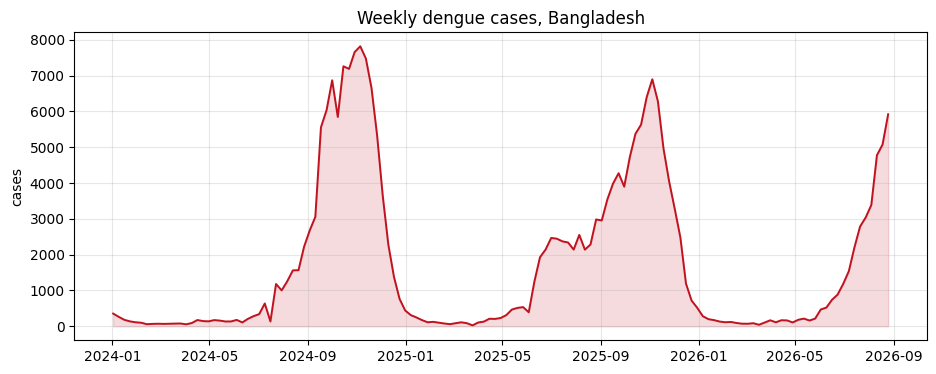

In [2]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(df['week'], df['total_cases'], color='#c1121f', lw=1.4)
ax.fill_between(df['week'], df['total_cases'], color='#c1121f', alpha=0.15)
ax.set_title('Weekly dengue cases, Bangladesh'); ax.set_ylabel('cases'); ax.grid(alpha=0.3); plt.show()

### Weather over time

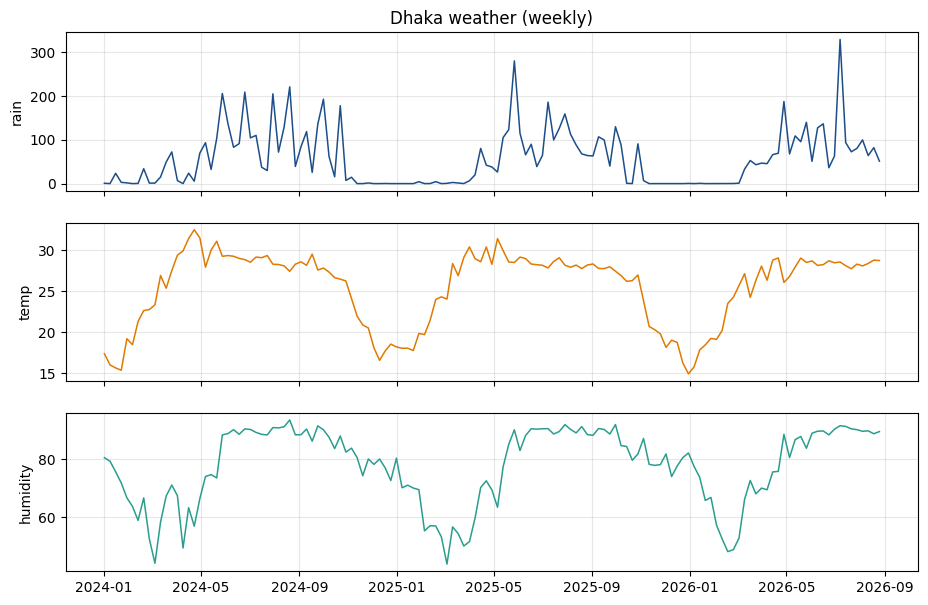

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)
for ax, col, color in zip(axes, ['rain','temp','humidity'], ['#1d4e89','#e07a00','#2a9d8f']):
    ax.plot(df['week'], df[col], color=color, lw=1.1); ax.set_ylabel(col); ax.grid(alpha=0.3)
axes[0].set_title('Dhaka weather (weekly)'); plt.show()

### Which rain lag matters most?

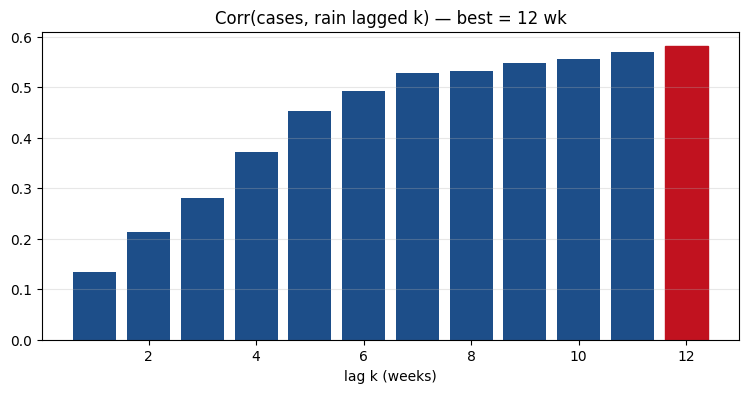

Strongest rain lag: 12 weeks


In [4]:
lags = range(1, 13)
corrs = [df['total_cases'].corr(df['rain'].shift(k)) for k in lags]
best = list(lags)[int(np.nanargmax(corrs))]
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(list(lags), corrs, color='#1d4e89'); bars[best-1].set_color('#c1121f')
ax.set_title(f'Corr(cases, rain lagged k) — best = {best} wk'); ax.set_xlabel('lag k (weeks)')
ax.grid(alpha=0.3, axis='y'); plt.show()
print('Strongest rain lag:', best, 'weeks')

### Seasonality by month

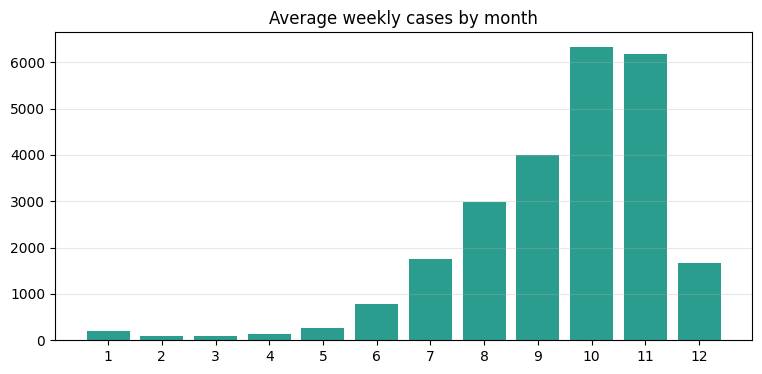

In [5]:
df['month'] = df['week'].dt.month
m = df.groupby('month')['total_cases'].mean()
fig, ax = plt.subplots(figsize=(9, 4)); ax.bar(m.index, m.values, color='#2a9d8f')
ax.set_xticks(range(1,13)); ax.set_title('Average weekly cases by month'); ax.grid(alpha=0.3, axis='y'); plt.show()

### Distribution & stationarity (ADF)

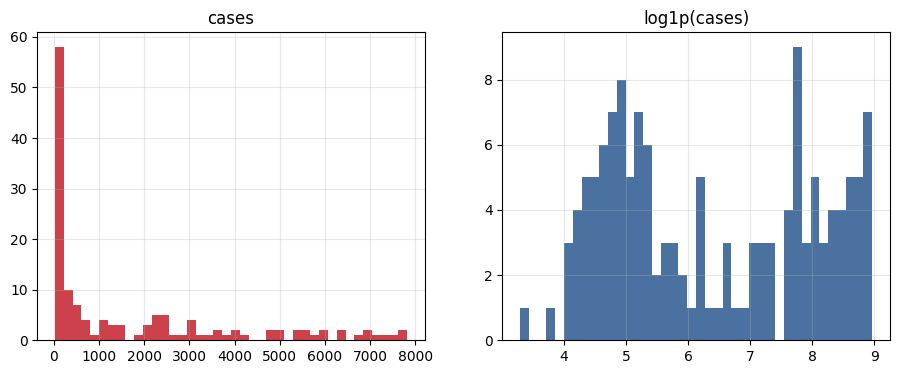

ADF p-value ~ 0.025 -> stationary-ish


/tmp/ipykernel_2798/880513530.py:8: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  p = adfuller(df['total_cases'].dropna())[1]


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(df['total_cases'], bins=40, color='#c1121f', alpha=0.8); axes[0].set_title('cases')
axes[1].hist(np.log1p(df['total_cases']), bins=40, color='#1d4e89', alpha=0.8); axes[1].set_title('log1p(cases)')
for a in axes: a.grid(alpha=0.3)
plt.show()
try:
    from statsmodels.tsa.stattools import adfuller
    p = adfuller(df['total_cases'].dropna())[1]
except Exception:
    x = df['total_cases'].astype(float).values; dx = np.diff(x); xl = x[:-1]
    Xr = np.column_stack([xl - xl.mean(), np.ones(len(xl))])
    beta, *_ = np.linalg.lstsq(Xr, dx, rcond=None); resid = dx - Xr @ beta
    se = np.sqrt((resid @ resid)/(len(dx)-2) * np.linalg.inv(Xr.T @ Xr)[0,0])
    t = beta[0]/se; p = 0.01 if t < -3.4 else (0.05 if t < -2.9 else 0.2)
    print('(statsmodels missing; approximate ADF)')
print(f'ADF p-value ~ {p:.3f} ->', 'stationary-ish' if p < 0.05 else 'trend/seasonality present')

**Takeaway:** strong seasonality + multi-week rain lag → lag/rolling features next. Next: **02**.